In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn import metrics 
import matplotlib.pyplot as plt

## df van excel bestand

In [42]:
df = pd.read_excel('AmesHousing.xlsx')
df

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


In [ ]:
df = df.loc[:, ['Overall Qual','SalePrice', 'Year Built','Neighborhood']]
df

KeyError: "['Garage', 'Neighborhood'] not in index"

## One-hot encoding

In [ ]:
dummies_dataframe = pd.get_dummies(df.loc[:, ['Neighborhood']], drop_first=True)
dummies_dataframe

,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2926,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2927,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## concat nieuwe df aan originele df met dropped house style

In [ ]:
df = pd.concat([df, dummies_dataframe], axis=1)
df = df.drop(['Neighborhood'], axis=1)
df

,Overall Qual,SalePrice,Year Built,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,215000,1960,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,5,105000,1961,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,172000,1958,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,244000,1968,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,189900,1997,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,6,142500,1984,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2926,5,131000,1983,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2927,5,132000,1992,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2928,5,170000,1974,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Definieer X en y

In [47]:
X = df[['Year Built', 'SalePrice', 'No Garage', 'With Garage']]

y = df['Overall Qual']
X

KeyError: "['No Garage', 'With Garage'] not in index"

## horizontaal en verticaal snijden van tabel 

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42)

## Decision tree maken

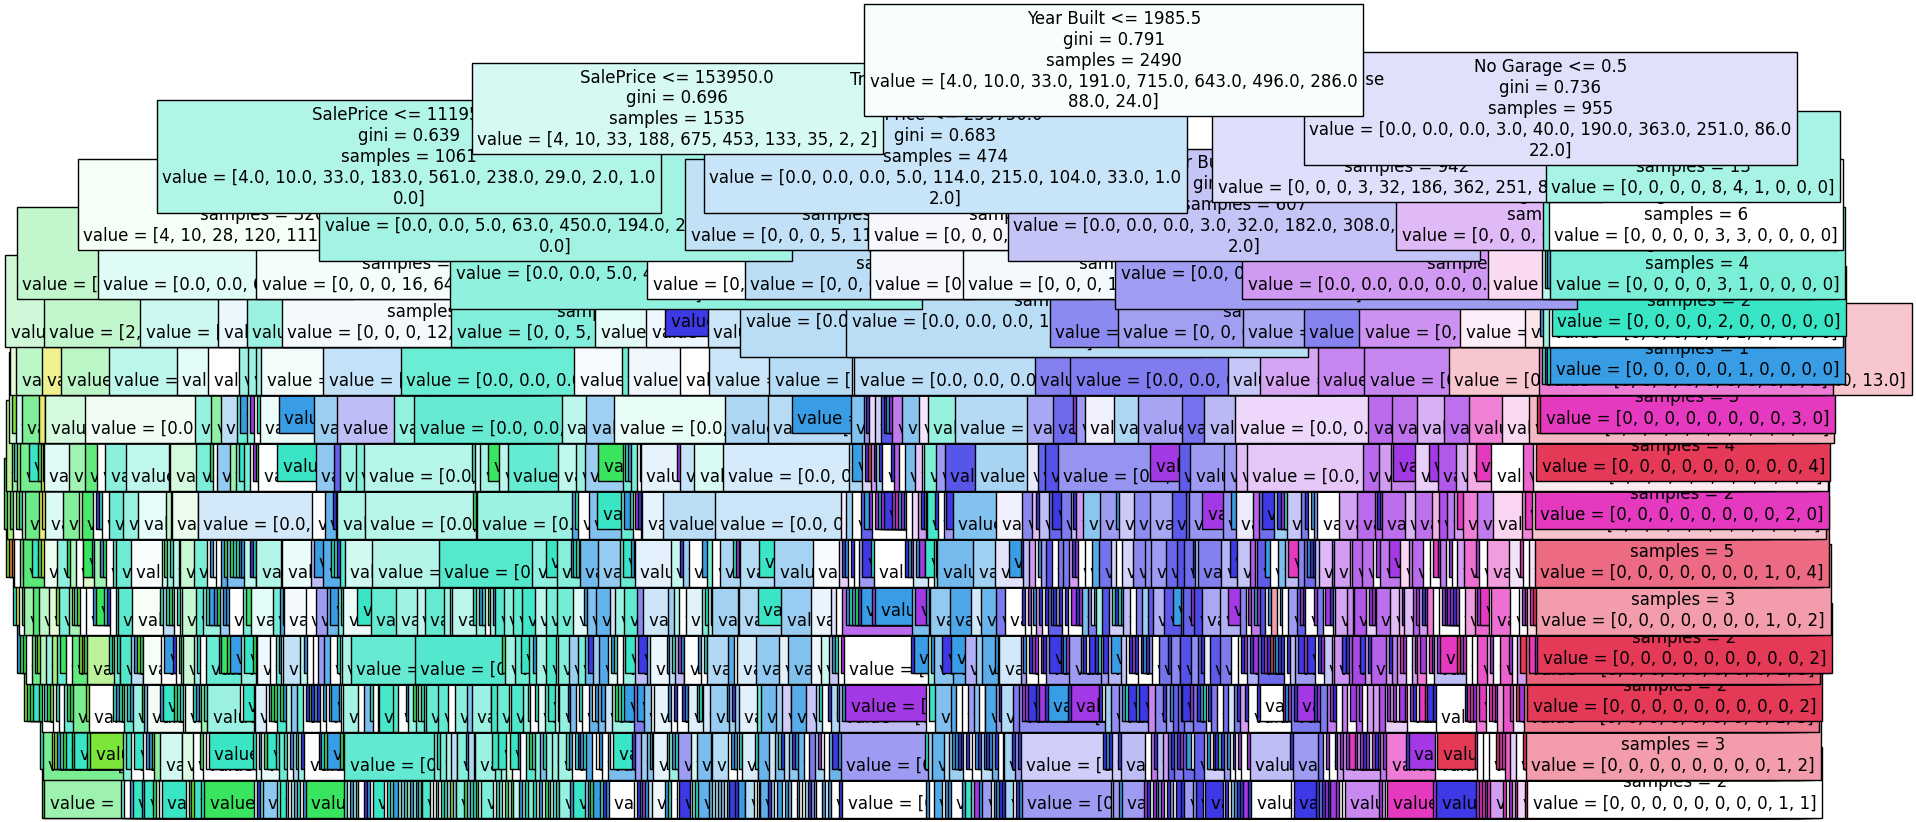

In [34]:
dtree = DecisionTreeClassifier(max_depth=15, max_features=2)
dtree = dtree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
tree.plot_tree(dtree, feature_names=X.columns, fontsize=12, filled=True)
plt.show()

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dtree.feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance

,Feature,Importance
1,SalePrice,0.582841
0,Year Built,0.401457
2,No Garage,0.009269
3,With Garage,0.006434


In [36]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns={0: 'Predicted Overall Qual'})
model_results_frame = pd.concat([y_test.reset_index(drop=True), predicted_df], axis=1)
model_results_frame

,Overall Qual,Predicted Overall Qual
0,8,5
1,6,5
2,7,7
3,4,5
4,6,5
...,...,...
435,7,8
436,5,4
437,5,5
438,6,7


In [37]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns={0: 'Predicted Overall Qual'})
model_results_frame = pd.concat([y_test.reset_index(drop=True), predicted_df], axis=1)

# Voeg kolom toe om correct/incorrect aan te geven
model_results_frame['Correct'] = model_results_frame['Overall Qual'] == model_results_frame['Predicted Overall Qual']

# Predictions per Qual samengevat
predictions_per_qual = model_results_frame.groupby('Overall Qual').agg({
    'Correct': ['sum', 'count'],
    'Predicted Overall Qual': 'count'
}).round(2)

predictions_per_qual.columns = ['Correct', 'Total', 'Count']
predictions_per_qual['Accuracy %'] = (100 * predictions_per_qual['Correct'] / predictions_per_qual['Total']).round(1)
predictions_per_qual['Incorrect'] = predictions_per_qual['Total'] - predictions_per_qual['Correct']

predictions_per_qual[['Correct', 'Incorrect', 'Total', 'Accuracy %']]

,Correct,Incorrect,Total,Accuracy %
Overall Qual,,,,
2,0,3,3,0.0
3,3,4,7,42.9
4,9,26,35,25.7
5,58,52,110,52.7
6,31,58,89,34.8
7,53,53,106,50.0
8,38,26,64,59.4
9,10,9,19,52.6
10,1,6,7,14.3


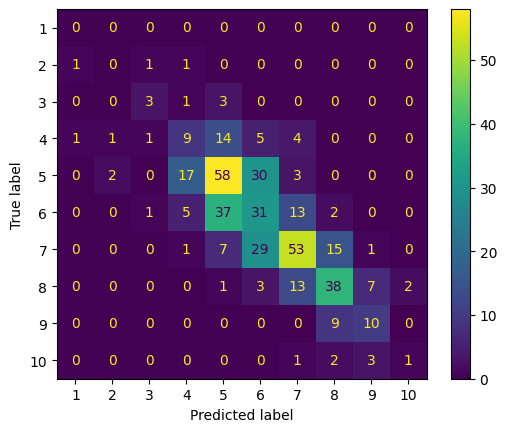

In [38]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['Overall Qual'], model_results_frame['Predicted Overall Qual'])
labels = sorted(set(list(y_test) + list(model_results_frame['Predicted Overall Qual'])))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels=labels)

cm_display.plot()
plt.show()

In [39]:
accuracy = accuracy_score(y_test, model_results_frame['Predicted Overall Qual'], )
precision = precision_score(y_test, model_results_frame['Predicted Overall Qual'], average='weighted', zero_division=0)
recall = recall_score(y_test, model_results_frame['Predicted Overall Qual'], average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

Accuracy:  0.461
Precision: 0.470
Recall:    0.461
